# **TASK 1 — Data Loading, EDA & Preprocessing**


**Load Dataset**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


**Load Dataset**

In [5]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


**Check Target**

In [6]:
print(y.value_counts())

target
1    357
0    212
Name: count, dtype: int64


**See the Data**

In [8]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Class Distribution Graph**

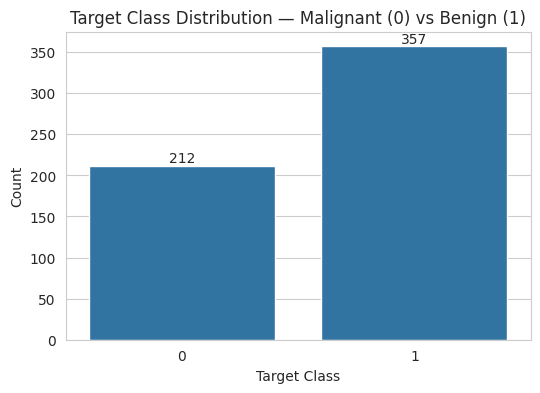

In [10]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x=y)

plt.title("Target Class Distribution — Malignant (0) vs Benign (1)")
plt.xlabel("Target Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Correlation Heatmap**

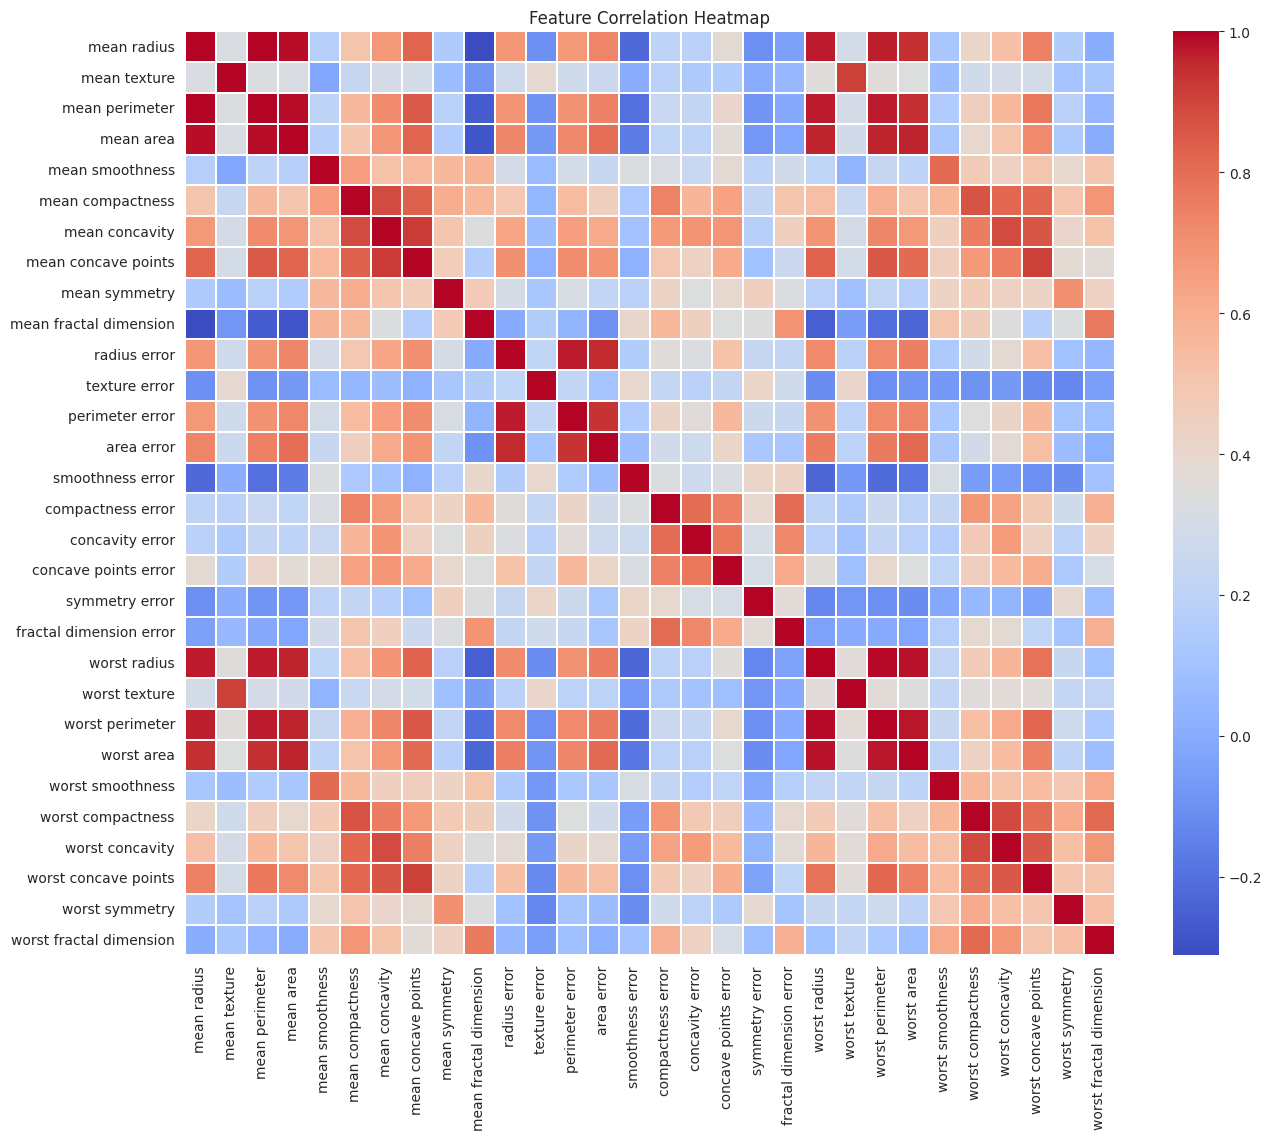

In [11]:
plt.figure(figsize=(15,12))

corr = X.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Train/Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


**Scaling**

In [13]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaling completed")
print("Training data:", X_train_sc.shape)
print("Testing data:", X_test_sc.shape)

Scaling completed
Training data: (455, 30)
Testing data: (114, 30)


**Check Scaling**

In [14]:
print("Mean:")
print(X_train_sc.mean(axis=0).round(2))

print("\nStandard Deviation:")
print(X_train_sc.std(axis=0).round(2))

Mean:
[-0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.
  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.]

Standard Deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# **STEP 2 — Task 2: Single-Layer Perceptron (SLP)**

**Create the SLP model**

In [15]:
slp_model = keras.Sequential([
    keras.layers.Dense(
        1,
        activation="sigmoid",
        input_shape=(30,)
    )
])

slp_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

**Compile the model**

In [16]:
slp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("SLP model compiled successfully")

SLP model compiled successfully


**Train the SLP**

In [17]:
slp_history = slp_model.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8998 - loss: 0.3660 - val_accuracy: 0.9130 - val_loss: 0.3401
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9046 - loss: 0.3327 - val_accuracy: 0.9130 - val_loss: 0.3182
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9193 - loss: 0.3058 - val_accuracy: 0.9130 - val_loss: 0.3008
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9267 - loss: 0.2840 - val_accuracy: 0.8913 - val_loss: 0.2857
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9267 - loss: 0.2656 - val_accuracy: 0.8913 - val_loss: 0.2727
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9267 - loss: 0.2499 - val_accuracy: 0.8913 - val_loss: 0.2614
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9291 - loss: 0.2366 - val_accuracy: 0.8913 - val_loss: 0.2516
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9315 - loss: 0.2248 - val_accuracy: 0.8913 - va

**Plot Loss**

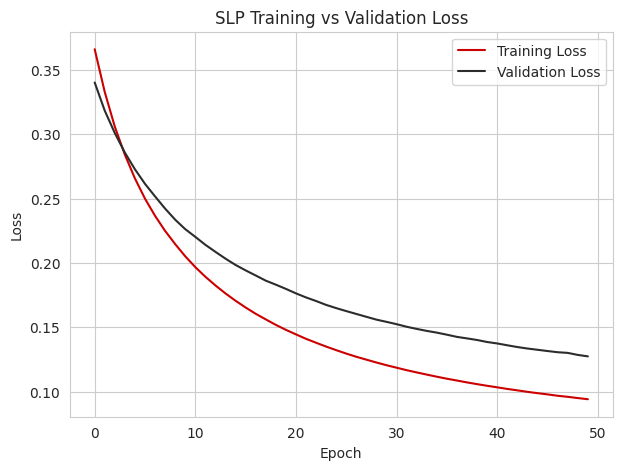

In [18]:
plt.figure(figsize=(7,5))

plt.plot(
    slp_history.history["loss"],
    label="Training Loss",
    color="#CC0000"
)

plt.plot(
    slp_history.history["val_loss"],
    label="Validation Loss",
    color="#2C2C2C"
)

plt.title("SLP Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Plot Accuracy**

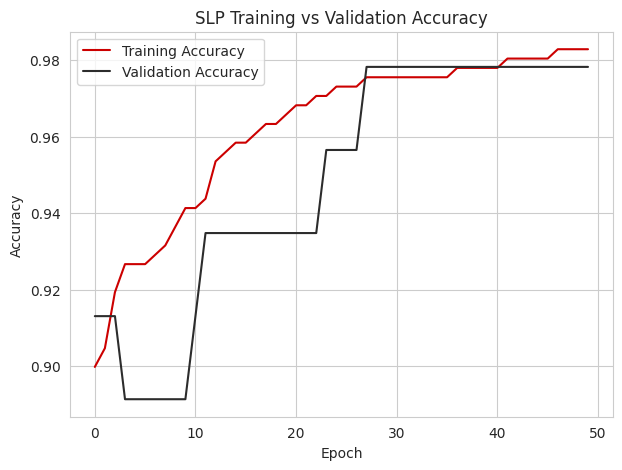

In [19]:
plt.figure(figsize=(7,5))

plt.plot(
    slp_history.history["accuracy"],
    label="Training Accuracy",
    color="#CC0000"
)

plt.plot(
    slp_history.history["val_accuracy"],
    label="Validation Accuracy",
    color="#2C2C2C"
)

plt.title("SLP Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Evaluate on Test Data**

In [20]:
slp_test_loss, slp_test_accuracy = slp_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("SLP Test Accuracy:", slp_test_accuracy)

SLP Test Accuracy: 0.9561403393745422


**Classification Report**

In [21]:
slp_probabilities = slp_model.predict(X_test_sc, verbose=0)

slp_predictions = (slp_probabilities >= 0.5).astype(int).ravel()

print(classification_report(
    y_test,
    slp_predictions,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Confusion Matrix**

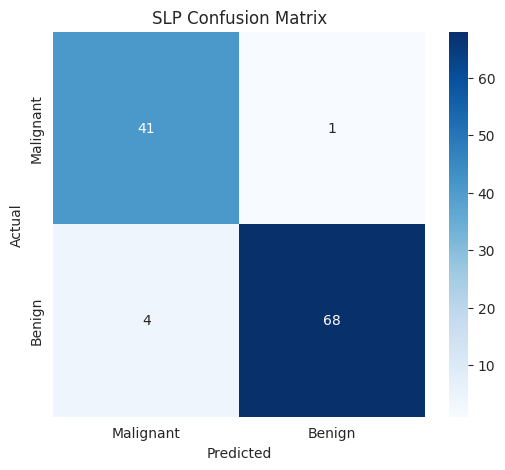

In [22]:
slp_cm = confusion_matrix(
    y_test,
    slp_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    slp_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("SLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **STEP 3 — Task 3: Multi-Layer Perceptron (MLP)**

**Create MLP with ReLU**

In [23]:
mlp_relu = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(30,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_relu.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

**Compile ReLU model**

In [24]:
mlp_relu.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MLP ReLU model compiled successfully")

MLP ReLU model compiled successfully


**Train ReLU model**

In [25]:
mlp_relu_history = mlp_relu.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8631 - loss: 0.4374 - val_accuracy: 0.9130 - val_loss: 0.3629
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9487 - loss: 0.2355 - val_accuracy: 0.9130 - val_loss: 0.2368
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9633 - loss: 0.1503 - val_accuracy: 0.9130 - val_loss: 0.1769
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9756 - loss: 0.1107 - val_accuracy: 0.9348 - val_loss: 0.1444
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9780 - loss: 0.0908 - val_accuracy: 0.9565 - val_loss: 0.1241
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9804 - loss: 0.0791 - val_accuracy: 0.9565 - val_loss: 0.1088
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9804 - loss: 0.0709 - val_accuracy: 0.9565 - val_loss: 0.0950
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9829 - loss: 0.0649 - val_accuracy: 0.

**Check Test Accuracy**

In [26]:
mlp_relu_loss, mlp_relu_accuracy = mlp_relu.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("MLP ReLU Test Accuracy:", mlp_relu_accuracy)

MLP ReLU Test Accuracy: 0.9561403393745422


**Create Tanh model**

In [27]:
mlp_tanh = keras.Sequential([
    keras.layers.Dense(64, activation="tanh", input_shape=(30,)),
    keras.layers.Dense(32, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_tanh.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MLP Tanh model created")

MLP Tanh model created


**Train Tanh model**

In [28]:
mlp_tanh_history = mlp_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8729 - loss: 0.3768 - val_accuracy: 0.9130 - val_loss: 0.2597
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9487 - loss: 0.1533 - val_accuracy: 0.9130 - val_loss: 0.1920
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9609 - loss: 0.1137 - val_accuracy: 0.9565 - val_loss: 0.1470
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9707 - loss: 0.0943 - val_accuracy: 0.9565 - val_loss: 0.1175
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9780 - loss: 0.0823 - val_accuracy: 0.9565 - val_loss: 0.0977
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - loss: 0.0751 - val_accuracy: 0.9783 - val_loss: 0.0865
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0697 - val_accuracy: 0.9783 - val_loss: 0.0822
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0657 - val_accuracy: 0.978

**Create Sigmoid hidden-layer model**

In [29]:
mlp_sigmoid = keras.Sequential([
    keras.layers.Dense(64, activation="sigmoid", input_shape=(30,)),
    keras.layers.Dense(32, activation="sigmoid"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_sigmoid.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MLP Sigmoid model created")

MLP Sigmoid model created


**Train Sigmoid model**

In [30]:
mlp_sigmoid_history = mlp_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.5086 - loss: 0.7159 - val_accuracy: 0.5217 - val_loss: 0.6619
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6430 - loss: 0.5916 - val_accuracy: 0.5000 - val_loss: 0.6446
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6748 - loss: 0.5292 - val_accuracy: 0.6087 - val_loss: 0.5751
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7971 - loss: 0.4649 - val_accuracy: 0.8478 - val_loss: 0.5059
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8900 - loss: 0.4059 - val_accuracy: 0.8478 - val_loss: 0.4349
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9267 - loss: 0.3466 - val_accuracy: 0.8696 - val_loss: 0.3797
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9340 - loss: 0.2964 - val_accuracy: 0.8913 - val_loss: 0.3299
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9462 - loss: 0.2542 - val_accuracy: 0

**Compare the three activation functions**

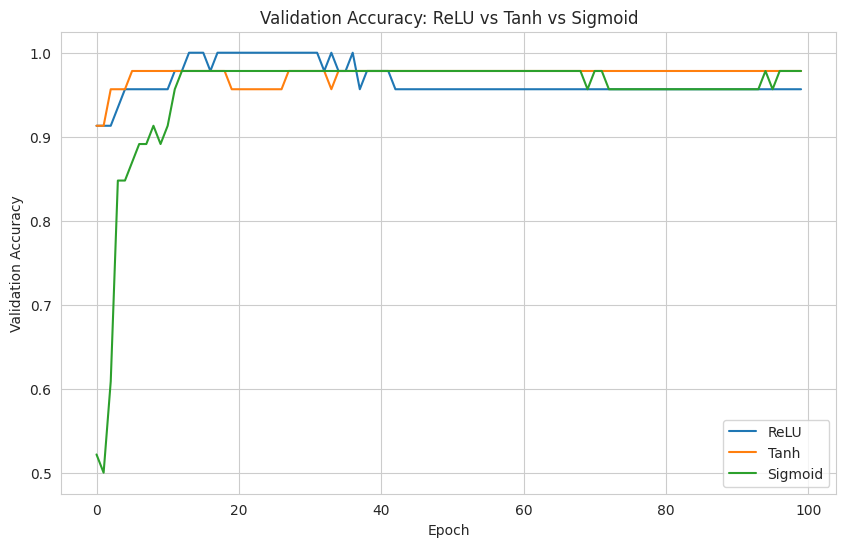

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    mlp_relu_history.history["val_accuracy"],
    label="ReLU"
)

plt.plot(
    mlp_tanh_history.history["val_accuracy"],
    label="Tanh"
)

plt.plot(
    mlp_sigmoid_history.history["val_accuracy"],
    label="Sigmoid"
)

plt.title("Validation Accuracy: ReLU vs Tanh vs Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

**Get Test Accuracy of all three**

In [32]:
_, relu_acc = mlp_relu.evaluate(X_test_sc, y_test, verbose=0)
_, tanh_acc = mlp_tanh.evaluate(X_test_sc, y_test, verbose=0)
_, sigmoid_acc = mlp_sigmoid.evaluate(X_test_sc, y_test, verbose=0)

print("ReLU Test Accuracy:", relu_acc)
print("Tanh Test Accuracy:", tanh_acc)
print("Sigmoid Test Accuracy:", sigmoid_acc)

ReLU Test Accuracy: 0.9561403393745422
Tanh Test Accuracy: 0.9649122953414917
Sigmoid Test Accuracy: 0.9561403393745422


**Create comparison table**

In [33]:
activation_results = pd.DataFrame({
    "Activation Function": ["ReLU", "Tanh", "Sigmoid"],
    "Test Accuracy": [relu_acc, tanh_acc, sigmoid_acc]
})

activation_results

,Activation Function,Test Accuracy
0,ReLU,0.956140
1,Tanh,0.964912
2,Sigmoid,0.956140


**Find the best activation**

In [34]:
best_activation = activation_results.loc[
    activation_results["Test Accuracy"].idxmax(),
    "Activation Function"
]

print("Best activation based on test accuracy:", best_activation)

Best activation based on test accuracy: Tanh


# **STEP 4 — Task 4: Early Stopping & Overfitting**

**Create the MLP model**

In [35]:
mlp_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mlp_es.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Create Early Stopping**

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("Early Stopping created")

Early Stopping created


**Train with Early Stopping**

In [37]:
mlp_es_history = mlp_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8362 - loss: 0.4552 - val_accuracy: 0.9130 - val_loss: 0.2860
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9658 - loss: 0.1753 - val_accuracy: 0.9130 - val_loss: 0.1946
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9658 - loss: 0.1104 - val_accuracy: 0.9565 - val_loss: 0.1438
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9756 - loss: 0.0833 - val_accuracy: 0.9565 - val_loss: 0.1142
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9829 - loss: 0.0703 - val_accuracy: 0.9565 - val_loss: 0.0954
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - loss: 0.0620 - val_accuracy: 0.9783 - val_loss: 0.0790
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.0553 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.0490 - val_accuracy: 0.978

**Find the actual stopping epoch**

In [38]:
stopping_epoch = len(mlp_es_history.history["loss"])

print("Training stopped at epoch:", stopping_epoch)

Training stopped at epoch: 272


**Plot Training vs Validation Loss**

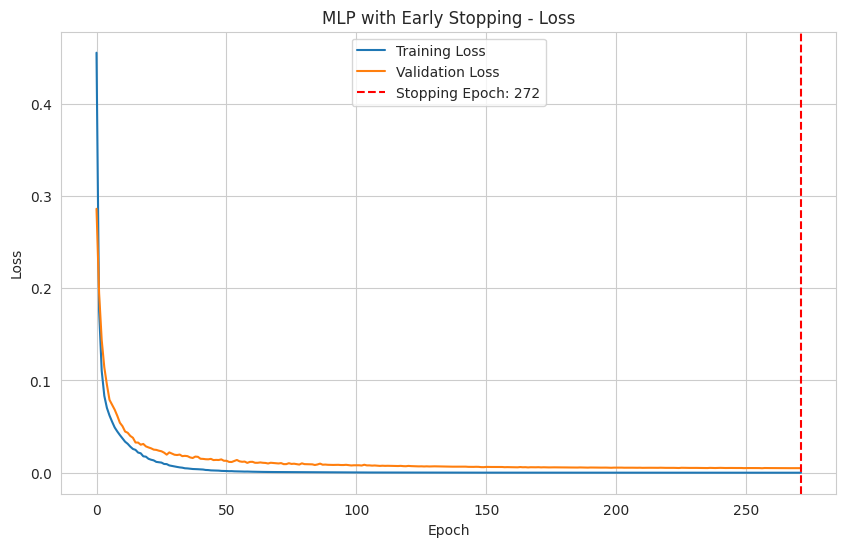

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    mlp_es_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mlp_es_history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    stopping_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Stopping Epoch: {stopping_epoch}"
)

plt.title("MLP with Early Stopping - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Evaluate Early Stopping model**

In [40]:
es_loss, es_accuracy = mlp_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("MLP + Early Stopping Test Accuracy:", es_accuracy)

MLP + Early Stopping Test Accuracy: 0.9561403393745422


**Create model WITHOUT Early Stopping**

In [41]:
mlp_no_es = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_no_es.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model without Early Stopping created")

Model without Early Stopping created


**Train without Early Stopping**

In [42]:
mlp_no_es_history = mlp_no_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8509 - loss: 0.4455 - val_accuracy: 0.9348 - val_loss: 0.2767
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1719 - val_accuracy: 0.9348 - val_loss: 0.1881
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1112 - val_accuracy: 0.9348 - val_loss: 0.1412
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.0826 - val_accuracy: 0.9565 - val_loss: 0.1029
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0671 - val_accuracy: 0.9783 - val_loss: 0.0833
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.0575 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.0507 - val_accuracy: 0.9783 - val_loss: 0.0644
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9902 - loss: 0.0447 - val_accuracy: 0.9783 - 

**Compare Validation Loss**

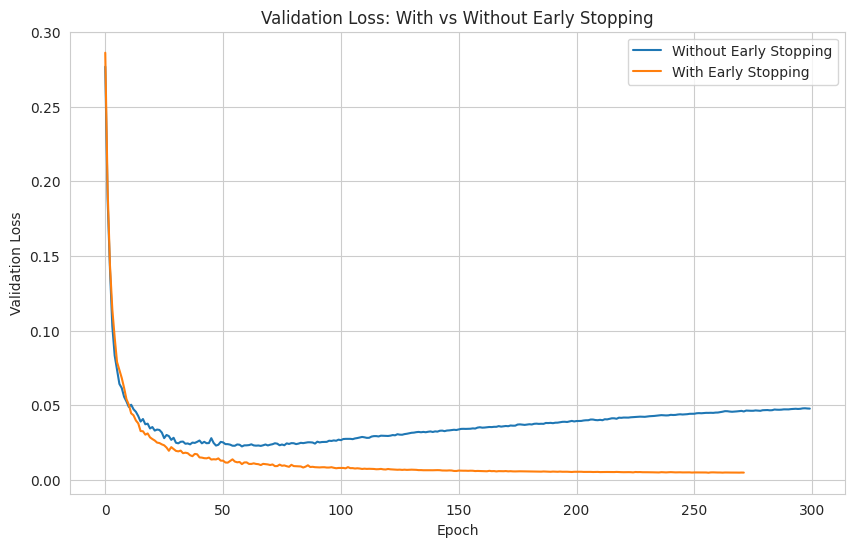

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    mlp_no_es_history.history["val_loss"],
    label="Without Early Stopping"
)

plt.plot(
    mlp_es_history.history["val_loss"],
    label="With Early Stopping"
)

plt.title("Validation Loss: With vs Without Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()

**Evaluate model without Early Stopping**

In [44]:
no_es_loss, no_es_accuracy = mlp_no_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("MLP Without Early Stopping Test Accuracy:", no_es_accuracy)

MLP Without Early Stopping Test Accuracy: 0.9561403393745422


**Compare the two models**

In [45]:
comparison = pd.DataFrame({
    "Model": [
        "MLP + Early Stopping",
        "MLP Without Early Stopping"
    ],
    "Test Accuracy": [
        es_accuracy,
        no_es_accuracy
    ]
})

comparison

,Model,Test Accuracy
0,MLP + Early Stopping,0.95614
1,MLP Without Early Stopping,0.95614


# **STEP 5 — Task 5: Dropout Regularization**

**Create the Dropout model**

In [46]:
dropout_model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Create Early Stopping**

In [47]:
dropout_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print("Early Stopping created")

Early Stopping created


**Train Dropout 0.3 model**

In [48]:
dropout_history = dropout_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[dropout_early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7237 - loss: 0.5360 - val_accuracy: 0.9130 - val_loss: 0.3144
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9364 - loss: 0.2211 - val_accuracy: 0.9130 - val_loss: 0.2002
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9560 - loss: 0.1472 - val_accuracy: 0.9130 - val_loss: 0.1552
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9609 - loss: 0.1120 - val_accuracy: 0.9348 - val_loss: 0.1292
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9731 - loss: 0.0956 - val_accuracy: 0.9565 - val_loss: 0.1032
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9756 - loss: 0.0792 - val_accuracy: 0.9783 - val_loss: 0.0882
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9853 - loss: 0.0690 - val_accuracy: 0.9783 - val_loss: 0.0796
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9804 - loss: 0.0635 - val_accuracy: 0.

**Evaluate Dropout 0.3**

In [49]:
dropout_loss, dropout_accuracy = dropout_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Dropout 0.3 Test Accuracy:", dropout_accuracy)

Dropout 0.3 Test Accuracy: 0.9649122953414917


**Compare different Dropout rates**

In [50]:
def create_dropout_model(rate):
    model = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(30,)),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

**Train Dropout 0.1**

In [51]:
model_01 = create_dropout_model(0.1)

early_01 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_01 = model_01.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_01],
    verbose=0
)

print("Dropout 0.1 training completed")

Dropout 0.1 training completed


**Train Dropout 0.3**

In [52]:
model_03 = create_dropout_model(0.3)

early_03 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_03 = model_03.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_03],
    verbose=0
)

print("Dropout 0.3 training completed")

Dropout 0.3 training completed


**Train Dropout 0.5**

In [53]:
model_05 = create_dropout_model(0.5)

early_05 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_05 = model_05.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_05],
    verbose=0
)

print("Dropout 0.5 training completed")

Dropout 0.5 training completed


**Plot validation accuracy**

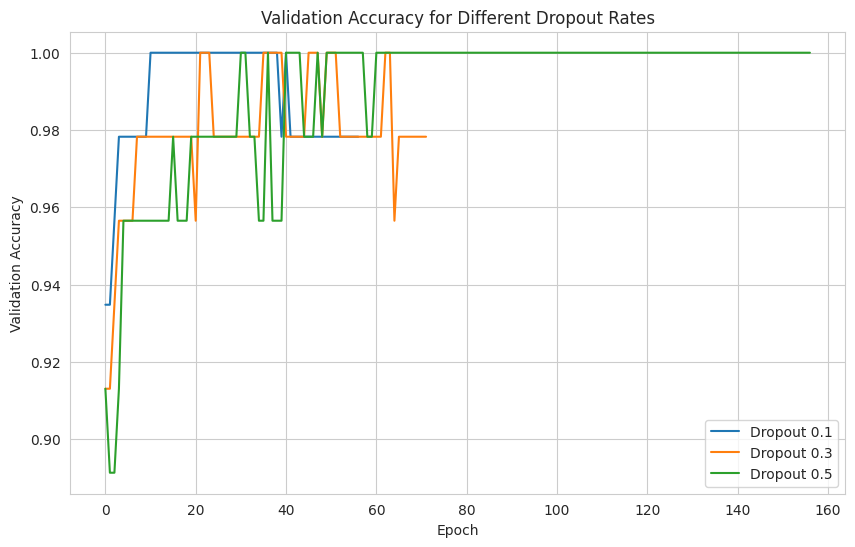

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_01.history["val_accuracy"],
    label="Dropout 0.1"
)

plt.plot(
    history_03.history["val_accuracy"],
    label="Dropout 0.3"
)

plt.plot(
    history_05.history["val_accuracy"],
    label="Dropout 0.5"
)

plt.title("Validation Accuracy for Different Dropout Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

**Test Accuracy of all three**

In [55]:
_, acc_01 = model_01.evaluate(X_test_sc, y_test, verbose=0)
_, acc_03 = model_03.evaluate(X_test_sc, y_test, verbose=0)
_, acc_05 = model_05.evaluate(X_test_sc, y_test, verbose=0)

print("Dropout 0.1 Test Accuracy:", acc_01)
print("Dropout 0.3 Test Accuracy:", acc_03)
print("Dropout 0.5 Test Accuracy:", acc_05)

Dropout 0.1 Test Accuracy: 0.9649122953414917
Dropout 0.3 Test Accuracy: 0.9561403393745422
Dropout 0.5 Test Accuracy: 0.9649122953414917


**Create comparison table**

In [56]:
dropout_results = pd.DataFrame({
    "Dropout Rate": [0.1, 0.3, 0.5],
    "Test Accuracy": [acc_01, acc_03, acc_05]
})

dropout_results

,Dropout Rate,Test Accuracy
0,0.1,0.964912
1,0.3,0.956140
2,0.5,0.964912


**Identify best dropout rate**

In [57]:
best_dropout_rate = dropout_results.loc[
    dropout_results["Test Accuracy"].idxmax(),
    "Dropout Rate"
]

print("Best Dropout Rate:", best_dropout_rate)

Best Dropout Rate: 0.1


# **STEP 6 — Task 6: L1, L2 & L1-L2 Regularization**

**Create L2 model**

In [58]:
l2_model = keras.Sequential([
    keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(30,)
    ),
    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l2_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train L2 model**

In [59]:
l2_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

l2_history = l2_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[l2_early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8509 - loss: 0.5483 - val_accuracy: 0.9348 - val_loss: 0.4306
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9609 - loss: 0.3049 - val_accuracy: 0.9348 - val_loss: 0.3361
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9682 - loss: 0.2418 - val_accuracy: 0.9348 - val_loss: 0.2821
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9804 - loss: 0.2135 - val_accuracy: 0.9565 - val_loss: 0.2407
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9829 - loss: 0.1995 - val_accuracy: 0.9565 - val_loss: 0.2172
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9829 - loss: 0.1874 - val_accuracy: 0.9565 - val_loss: 0.2057
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9853 - loss: 0.1777 - val_accuracy: 0.9565 - val_loss: 0.1928
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9853 - loss: 0.1689 - val_accuracy: 0.

**Evaluate L2**

In [60]:
l2_loss, l2_accuracy = l2_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("L2 Test Accuracy:", l2_accuracy)

L2 Test Accuracy: 0.9561403393745422


**Create L1 model**

In [61]:
l1_model = keras.Sequential([
    keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001),
        input_shape=(30,)
    ),
    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001)
    ),
    keras.layers.Dense(1, activation="sigmoid")
])

l1_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l1_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train L1 model**

In [62]:
l1_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

l1_history = l1_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[l1_early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9095 - loss: 1.4742 - val_accuracy: 0.9348 - val_loss: 1.3383
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9584 - loss: 1.2121 - val_accuracy: 0.9348 - val_loss: 1.2077
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9707 - loss: 1.1122 - val_accuracy: 0.9565 - val_loss: 1.1166
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 1.0350 - val_accuracy: 0.9565 - val_loss: 1.0362
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.9678 - val_accuracy: 0.9565 - val_loss: 0.9632
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9853 - loss: 0.9036 - val_accuracy: 0.9565 - val_loss: 0.9001
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.8419 - val_accuracy: 0.9565 - val_loss: 0.8365
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.7830 - val_accuracy: 0.9565 -

**Evaluate L1**

In [63]:
l1_loss, l1_accuracy = l1_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("L1 Test Accuracy:", l1_accuracy)

L1 Test Accuracy: 0.9561403393745422


**Create L1-L2 model**

In [64]:
l1_l2_model = keras.Sequential([
    keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        ),
        input_shape=(30,)
    ),
    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    keras.layers.Dense(1, activation="sigmoid")
])

l1_l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l1_l2_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train L1-L2 model**

In [65]:
l1_l2_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

l1_l2_history = l1_l2_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[l1_l2_early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8460 - loss: 0.6971 - val_accuracy: 0.8913 - val_loss: 0.5714
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.4340 - val_accuracy: 0.9348 - val_loss: 0.4309
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9658 - loss: 0.3516 - val_accuracy: 0.9565 - val_loss: 0.3619
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.3140 - val_accuracy: 0.9783 - val_loss: 0.3208
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.2920 - val_accuracy: 0.9783 - val_loss: 0.2976
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.2761 - val_accuracy: 0.9783 - val_loss: 0.2865
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.2629 - val_accuracy: 0.9783 - val_loss: 0.2720
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.2502 - val_accuracy: 0.9783 - 

**Evaluate L1-L2**

In [66]:
l1_l2_loss, l1_l2_accuracy = l1_l2_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("L1-L2 Test Accuracy:", l1_l2_accuracy)

L1-L2 Test Accuracy: 0.9561403393745422


**Plot Training vs Validation Loss**

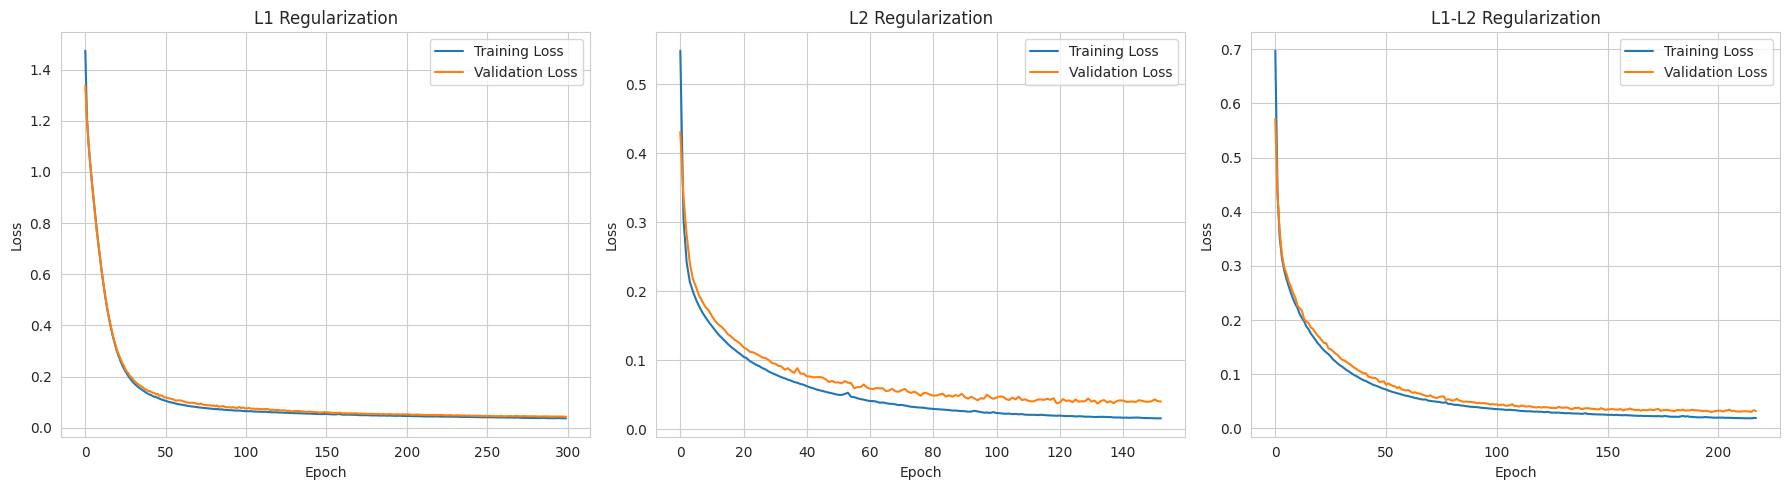

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(l1_history.history["loss"], label="Training Loss")
axes[0].plot(l1_history.history["val_loss"], label="Validation Loss")
axes[0].set_title("L1 Regularization")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(l2_history.history["loss"], label="Training Loss")
axes[1].plot(l2_history.history["val_loss"], label="Validation Loss")
axes[1].set_title("L2 Regularization")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(l1_l2_history.history["loss"], label="Training Loss")
axes[2].plot(l1_l2_history.history["val_loss"], label="Validation Loss")
axes[2].set_title("L1-L2 Regularization")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

**Create a model without regularization**

In [68]:
no_reg_model = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(30,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

no_reg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

no_reg_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

no_reg_history = no_reg_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[no_reg_early_stopping],
    verbose=0
)

_, no_reg_accuracy = no_reg_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("No Regularization Test Accuracy:", no_reg_accuracy)

No Regularization Test Accuracy: 0.9561403393745422


**Create accuracy comparison**

In [69]:
regularization_results = pd.DataFrame({
    "Model": [
        "No Regularization",
        "L1",
        "L2",
        "L1-L2"
    ],
    "Test Accuracy": [
        no_reg_accuracy,
        l1_accuracy,
        l2_accuracy,
        l1_l2_accuracy
    ]
})

regularization_results

,Model,Test Accuracy
0,No Regularization,0.95614
1,L1,0.95614
2,L2,0.95614
3,L1-L2,0.95614


**Create grouped bar chart**

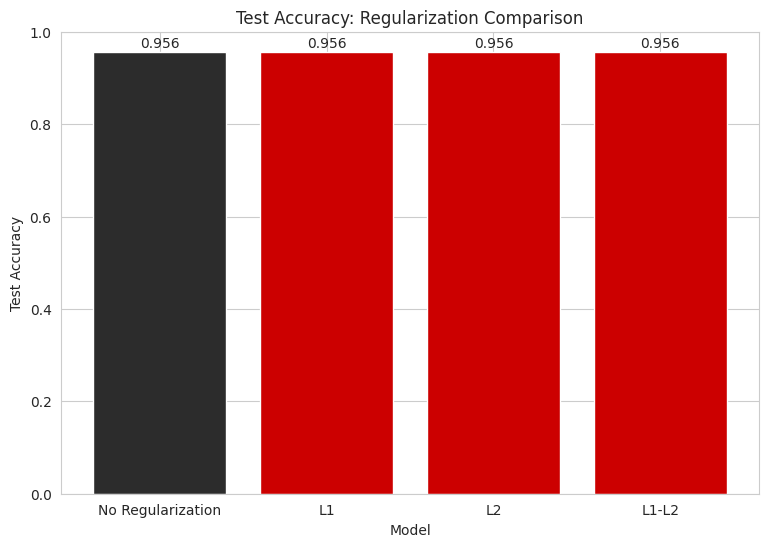

In [70]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    regularization_results["Model"],
    regularization_results["Test Accuracy"],
    color=["#2C2C2C", "#CC0000", "#CC0000", "#CC0000"]
)

plt.title("Test Accuracy: Regularization Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.show()

# **STEP 7 — Final Model, Results & Clinical Insight**

**Create Final Model**

In [71]:
final_model = keras.Sequential([
    keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(30,)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping**

In [72]:
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

**Train Final Model**

In [73]:
final_history = final_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[final_early_stopping],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8117 - loss: 0.6028 - val_accuracy: 0.9348 - val_loss: 0.4173
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9340 - loss: 0.3471 - val_accuracy: 0.9565 - val_loss: 0.3210
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9633 - loss: 0.2701 - val_accuracy: 0.9565 - val_loss: 0.2701
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9658 - loss: 0.2443 - val_accuracy: 0.9783 - val_loss: 0.2395
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9756 - loss: 0.2199 - val_accuracy: 0.9783 - val_loss: 0.2209
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9756 - loss: 0.2014 - val_accuracy: 0.9783 - val_loss: 0.2047
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9878 - loss: 0.2009 - val_accuracy: 0.9783 - val_loss: 0.1929
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9853 - loss: 0.1903 - val_accuracy: 0.

**Plot Final Model Loss**

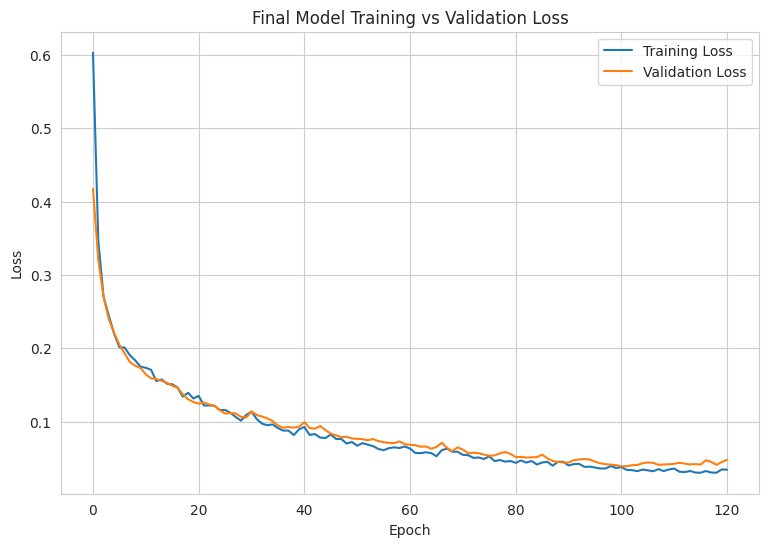

In [74]:
plt.figure(figsize=(9, 6))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Final Model Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Plot Final Model Accuracy**

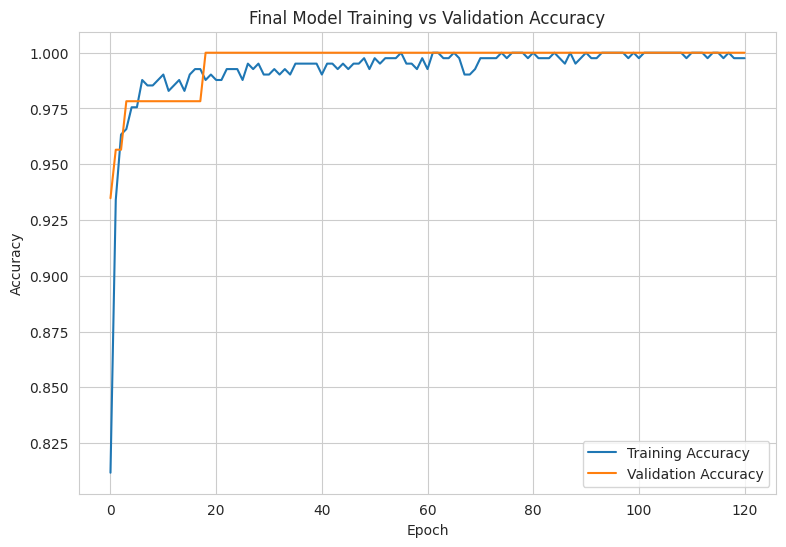

In [75]:
plt.figure(figsize=(9, 6))

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Final Model Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Evaluate Final Model**

In [76]:
final_loss, final_accuracy = final_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Final Model Test Accuracy:", final_accuracy)

Final Model Test Accuracy: 0.9561403393745422


**Generate Predictions**

In [77]:
final_probabilities = final_model.predict(
    X_test_sc,
    verbose=0
)

final_predictions = (
    final_probabilities >= 0.5
).astype(int).ravel()

**Classification Report**

In [78]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Confusion Matrix**

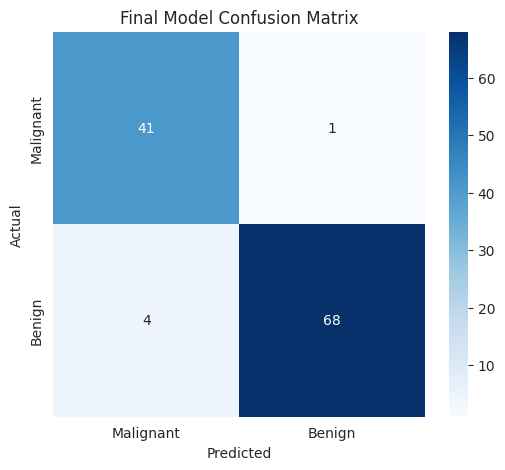

In [79]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Calculate Precision, Recall and F1**

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1-Score :", final_f1)

Accuracy : 0.9561403393745422
Precision: 0.9855072463768116
Recall   : 0.9444444444444444
F1-Score : 0.9645390070921985


**Create Final Results DataFrame**

In [81]:
results = pd.DataFrame([
    {
        "Model": "SLP",
        "Architecture": "30 → 1",
        "Regularization": "None",
        "Dropout Rate": 0,
        "Early Stopping": "No",
        "Test Accuracy": slp_test_accuracy,
        "Test Precision": precision_score(y_test, slp_predictions),
        "Test Recall": recall_score(y_test, slp_predictions),
        "Test F1-Score": f1_score(y_test, slp_predictions)
    },

    {
        "Model": "MLP-ReLU",
        "Architecture": "30 → 64 → 32 → 1",
        "Regularization": "None",
        "Dropout Rate": 0,
        "Early Stopping": "No",
        "Test Accuracy": relu_acc,
        "Test Precision": precision_score(
            y_test,
            (mlp_relu.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test Recall": recall_score(
            y_test,
            (mlp_relu.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test F1-Score": f1_score(
            y_test,
            (mlp_relu.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        )
    },

    {
        "Model": "MLP+ES",
        "Architecture": "30 → 128 → 64 → 1",
        "Regularization": "None",
        "Dropout Rate": 0,
        "Early Stopping": "Yes",
        "Test Accuracy": es_accuracy,
        "Test Precision": precision_score(
            y_test,
            (mlp_es.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test Recall": recall_score(
            y_test,
            (mlp_es.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test F1-Score": f1_score(
            y_test,
            (mlp_es.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        )
    },

    {
        "Model": "MLP+Dropout-best",
        "Architecture": "30 → 128 → 64 → 1",
        "Regularization": "Dropout",
        "Dropout Rate": best_dropout_rate,
        "Early Stopping": "Yes",
        "Test Accuracy": max(acc_01, acc_03, acc_05),
        "Test Precision": precision_score(
            y_test,
            (
                [
                    model_01,
                    model_03,
                    model_05
                ][
                    np.argmax([acc_01, acc_03, acc_05])
                ].predict(X_test_sc, verbose=0) >= 0.5
            ).astype(int).ravel()
        ),
        "Test Recall": recall_score(
            y_test,
            (
                [
                    model_01,
                    model_03,
                    model_05
                ][
                    np.argmax([acc_01, acc_03, acc_05])
                ].predict(X_test_sc, verbose=0) >= 0.5
            ).astype(int).ravel()
        ),
        "Test F1-Score": f1_score(
            y_test,
            (
                [
                    model_01,
                    model_03,
                    model_05
                ][
                    np.argmax([acc_01, acc_03, acc_05])
                ].predict(X_test_sc, verbose=0) >= 0.5
            ).astype(int).ravel()
        )
    },

    {
        "Model": "MLP+L2",
        "Architecture": "30 → 128 → 64 → 1",
        "Regularization": "L2",
        "Dropout Rate": 0,
        "Early Stopping": "Yes",
        "Test Accuracy": l2_accuracy,
        "Test Precision": precision_score(
            y_test,
            (l2_model.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test Recall": recall_score(
            y_test,
            (l2_model.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        ),
        "Test F1-Score": f1_score(
            y_test,
            (l2_model.predict(X_test_sc, verbose=0) >= 0.5).astype(int).ravel()
        )
    },

    {
        "Model": "Final Combined Model",
        "Architecture": "30 → 128 → 64 → 1",
        "Regularization": "L2",
        "Dropout Rate": 0.3,
        "Early Stopping": "Yes",
        "Test Accuracy": final_accuracy,
        "Test Precision": final_precision,
        "Test Recall": final_recall,
        "Test F1-Score": final_f1
    }
])

results

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1,None,0.0,No,0.956140,0.985507,0.944444,0.964539
1,MLP-ReLU,30 → 64 → 32 → 1,None,0.0,No,0.956140,0.985507,0.944444,0.964539
2,MLP+ES,30 → 128 → 64 → 1,None,0.0,Yes,0.956140,0.985507,0.944444,0.964539
3,MLP+Dropout-best,30 → 128 → 64 → 1,Dropout,0.1,Yes,0.964912,0.985714,0.958333,0.971831
4,MLP+L2,30 → 128 → 64 → 1,L2,0.0,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined Model,30 → 128 → 64 → 1,L2,0.3,Yes,0.956140,0.985507,0.944444,0.964539


**Highlight Best Results**

In [82]:
results.style.highlight_max(
    subset=[
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-Score"
    ],
    color="lightgreen"
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1,None,0.000000,No,0.956140,0.985507,0.944444,0.964539
1,MLP-ReLU,30 → 64 → 32 → 1,None,0.000000,No,0.956140,0.985507,0.944444,0.964539
2,MLP+ES,30 → 128 → 64 → 1,None,0.000000,Yes,0.956140,0.985507,0.944444,0.964539
3,MLP+Dropout-best,30 → 128 → 64 → 1,Dropout,0.100000,Yes,0.964912,0.985714,0.958333,0.971831
4,MLP+L2,30 → 128 → 64 → 1,L2,0.000000,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined Model,30 → 128 → 64 → 1,L2,0.300000,Yes,0.956140,0.985507,0.944444,0.964539
